# 10 — Getting started

The motivation behind scikit-ops is to allow very repeatable, very precise,
isolated environments to hold dependencies that potentially conflict with the
host environment — for example, a dependency that can't be installed alongside
the latest version of napari. The scikit-ops framework, via appose, takes care
of the details of that installation. The host dependencies are simple and easy for 
the user to install.

Here we install the host, run one op, check the GPU, and fetch the images.

## Install

Start from a clean environment. Python 3.12 or newer.

```sh
conda create -n i2k2026 python=3.12
conda activate i2k2026
```

Then the host — notebook kernel and napari, no torch, no TensorFlow, no CUDA.

```sh
pip install "scikit-ops @ git+https://github.com/apposed/scikit-ops.git"
pip install napari-ai-lab "napari[all]" "tnia-python[plotting]" jupyterlab matplotlib scikit-image tifffile albumentations
```

Note: `albumentations` is needed by `napari-ai-lab`'s
`AlbumentationsAugmenter` (used in notebook 52) but is not declared as
one of its dependencies, so it has to be installed explicitly.


In [14]:
import skop
import napari_ai_lab

print('skop         ', skop.__file__)
print('napari_ai_lab', napari_ai_lab.__file__)

skop          C:\Users\bnort\work\ImageJ2022\tnia\i2k-2026\pixi\.pixi\envs\default\Lib\site-packages\skop\__init__.py
napari_ai_lab C:\Users\bnort\work\ImageJ2022\tnia\i2k-2026\pixi\.pixi\envs\default\Lib\site-packages\napari_ai_lab\__init__.py


## Why micro_sam is in this environment

- We need it for interactive labelling
- SAM creates 'embeddings' which are medium expensive (20-60 seconds)
- For interactive labelling we want to keep the embedding in memory
  - First interactive label takes 20-60 seconds
  - The rest are a fast (a second or so)
- Currently microsam needs to be in host environment so the embeddings are available
- In the future ops should keep some artifacts (models, embeddings, histograms) persistent between calls.
  
**Isolation is for dependencies that are incompatible, not dependencies
that are complicated.**

This environment is not simple. It carries torch, CUDA and micro_sam. However it doesn't carry things that disagree.  

- Cellpose 3 and Cellpose 4 together. Either one could live here; both cannot.
- StarDist needs TensorFlow, which will not sit beside a recent PyTorch. On
  Windows least of all.

In [15]:
import micro_sam, torch
from micro_sam.multi_dimensional_segmentation import segment_mask_in_volume
from micro_sam.sam_annotator._state import AnnotatorState
from micro_sam.sam_annotator.util import prompt_segmentation

print('micro_sam', micro_sam.__version__)
print('torch    ', torch.__version__, '| CUDA:', torch.cuda.is_available())
print("SAM3D's entry points import OK")

micro_sam 1.8.14
torch     2.10.0 | CUDA: True
SAM3D's entry points import OK


## Does an op run, and does it report back?

`slow_sum` runs in the light `minimal` env and emits four progress events.

In [16]:
import numpy as np
from skop.runner import Runner
from skop.ops.toy import slow_sum

runner = Runner()

def show(ev):
    print('EVENT', ev.current, ev.maximum, ev.message, flush=True)

total = runner.run(slow_sum, image=np.ones((4, 4), np.float32), steps=4,
                   on_progress=show)
print('result:', total)

EVENT None None None
EVENT 0 4 Summing chunk 1 of 4
EVENT 1 4 Summing chunk 2 of 4
EVENT 2 4 Summing chunk 3 of 4
EVENT 3 4 Summing chunk 4 of 4
EVENT None None None
result: 16.0


## The StarDist environment

`up to date` returns at once. `stale` or `missing` rebuilds — minutes and
gigabytes, so do it before the session.

In [17]:
print('status:', runner.environment_status('stardist-tf'))
runner.ensure_environment('stardist-tf')

status: up to date
stardist-tf: up to date


<appose.builder.BaseBuilder._create_env.<locals>.BuiltEnvironment at 0x19125919a60>

## Is the GPU visible?

In the below cell we query the stardist environment that appose and the scikit-ops framework created to see if we have a GPU.   The trick is we use pixi to run the python snippet that looks for the GPU, and point pixi to the location of the scikit-ops stardist-tf pixi.toml.

In [18]:
# Through `pixi run`: calling the env's python directly skips activation and
# reports if there are GPUs in the environment
manifest = runner.env_dir('stardist-tf') / 'pixi.toml'

#!pixi run --manifest-path {manifest} python -c "import tensorflow as tf; print('GPUs:', tf.config.list_physical_devices('GPU'))" 2>&1 | grep -Ei 'gpus:|could not load'
!pixi run --manifest-path {manifest} python -c "import tensorflow as tf; print(\"GPUs:\", tf.config.list_physical_devices(\"GPU\"))" 

GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


 WARN Using local manifest C:\Users\bnort\.local\share\appose\skop-stardist-tf\pixi.toml rather than C:\Users\bnort\work\ImageJ2022\tnia\i2k-2026\pixi\pixi.toml from environment variable `PIXI_PROJECT_MANIFEST`


## Get the images

After running this command we should find a data directory in our notebooks directory which contains.

- a set of pollen images (easiest, possibly we can find all the pollen by tweaking cellpose parameters)
- a set of bee images (medium hard, probably need to do fine tuning to find only bees and not honeycomb cells)
- a set of lady bug images (hard, even after quite a bit of labelling and fine tuning hard to find them all) 

In [19]:
import urllib.request
import zipfile
from pathlib import Path

URL = 'https://www.dropbox.com/scl/fo/ock3qfwx11mvbfuih0hsc/AGk9LFOqnfm3HG_zw22vIv8?rlkey=aaoac1euyg89hpadnms96e2c9&st=4ck6sxe3&dl=1'   # must end in ?dl=1
DATA = Path('data') 
ZIP = Path('data') / 'data.zip'

# Set to True to download again and overwrite data/ -- this replaces any
# labels you have saved there with the ones in the download.
OVERWRITE = False

if OVERWRITE or not (DATA / 'bees').is_dir():
    DATA.mkdir(parents=True, exist_ok=True)
    urllib.request.urlretrieve(URL, ZIP)

    with zipfile.ZipFile(ZIP) as z:
        z.extractall(DATA)

    # delete the archive
    ZIP.unlink()
else:
    print('data/ already downloaded; set OVERWRITE = True to download again')

print(sorted(p.name for p in DATA.iterdir() if p.is_dir()))

[]


## Load one back

Check the files are where we think they are.

(1371, 2048, 3) uint8


(np.float64(-0.5), np.float64(2047.5), np.float64(1370.5), np.float64(-0.5))

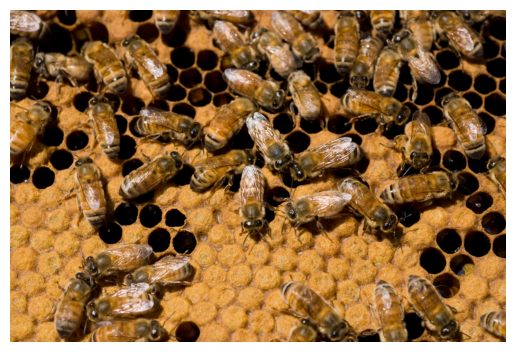

In [20]:
from skimage.io import imread
import matplotlib.pyplot as plt

img = imread(DATA / 'bees' / 'comb_03.png')
print(img.shape, img.dtype)

plt.imshow(img)
plt.axis('off')